# Практическая работа №5: Элементы регрессионного анализа. Выборочные прямые среднеквадратической регрессии. Корреляционные отношения

Выполнили студентки гр. 2383 Щёголева Надежда и Семененко Анна. Вариант №28

## Цель работы

Ознакомление с основными положениями метода наименьших квадратов (МНК), со статистическими свойствами МНК-оценок, с понятием функции регрессии и роли МНК в регрессионном анализе, с корреляционным отношением, как мерой тесноты произвольной (в том числе и линейной) корреляционной связи.

## Основные теоретические положения

Выборочные прямые среднеквадратической регрессии

Линейная функция среднеквадратической регрессии Y на X

$$g(x) = m(Y/x) = m(Y) + r_{xy}\cfrac{\omega_y}{\omega_x}[x-m(X)]$$

Уравнения выборочных прямых среднеквадратической регрессии получаются на основе уравнений линейных среднеквадратических регрессий, в которых все параметры распределений заменяются их статистическими оценками:
$$\bar y_x = \bar y_в + \bar r_{xy} \cfrac {S_y}{S_x}(x - \bar x_в)$$

Выборочное корреляционное отношение X к Y

$$\bar\eta_{xy} = \cfrac{\bar\sigma_{\bar x_y}}{\bar \sigma_x}$$

Выборочное корреляционное отношение Y к X

$$\bar\eta_{yx} = \cfrac{\bar\sigma_{\bar y_x}}{\bar \sigma_y}$$
, где $\bar\sigma_{\bar x_y} = \sqrt{D_{межгр}}$

## Постановка задачи

Для заданной двумерной выборки (X,Y) построить уравнения выборочных прямых среднеквадратической регрессии. Полученные линейные функции регрессии отобразить графически. Найти выборочное корреляционное отношение. Полученные результаты содержательно проинтерпретировать.



## Выполнение работы

1. Отобразим двумерную выборку на графике.

In [ ]:
import pandas as pd
import math
import matplotlib.pyplot as plt
import numpy as np
df = pd.read_csv('penguins.csv')
N = 117
x_B = 43.941
y_B = 16.144
S_x = 4.786
S_y = 2.055
r = -0.56

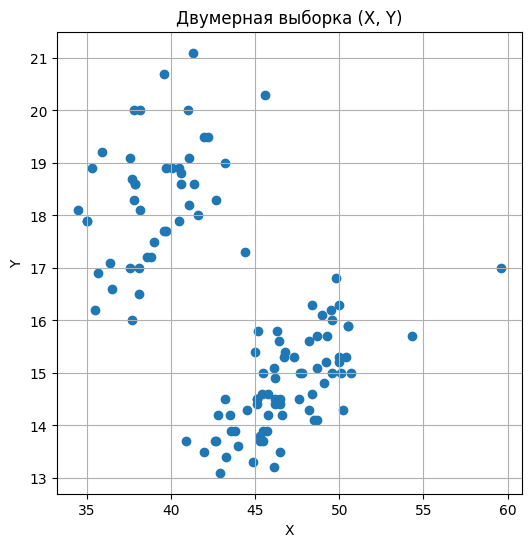

In [ ]:
x = df.iloc[:, 0]
y = df.iloc[:, 1]

plt.figure(figsize=(6, 6))
plt.scatter(x, y)

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Двумерная выборка (X, Y)')
plt.grid(True)

plt.show()

2. Для заданной выборки построим уравнения средней квадратичной регрессии x
 на y и y на x соответственно.
 Построить полученные прямые на множестве выборки. Объяснить результаты.

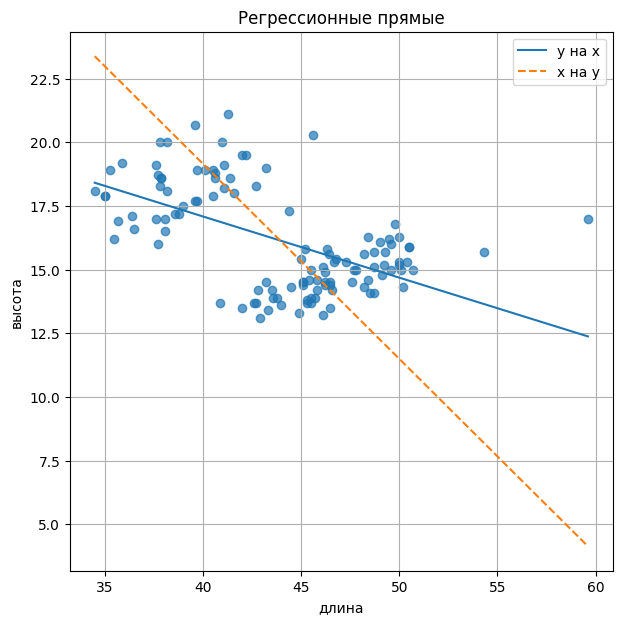

In [ ]:
# линия регрессии y(x)
x_line = np.linspace(min(x), max(x), 100)
y_line = y_B + r * (S_y / S_x) * (x_line - x_B)

y_line2 = y_B + (S_y/(S_x * r)) * (x_line - x_B)

plt.figure(figsize=(7, 7))
plt.scatter(x, y, alpha=0.7)

# прямые регрессии
plt.plot(x_line, y_line, label='y на x')
plt.plot(x_line, y_line2, linestyle='--', label='x на y')

plt.xlabel('длина')
plt.ylabel('высота')
plt.title('Регрессионные прямые')
plt.legend()
plt.grid(True)

plt.show()

Синяя прямая показывает как меняется высота при увеличении длины клюва, по наклону прямой можно сделать вывод, что при увеличении длины клюва, его высота уменьшается.

Оранжевая прямая показывает как в среднем меняется длина при изменении высоты клюва, по ней можно сказать, что в среднем чем выше клюв, тем он короче.

 На графике видно, что линии регрессии пересекаются в точке с координатами, равными выборочным средним этих случайных величин.

3. Составим корреляционную таблицу для нахождения выборочного корреляционного отношения.

In [ ]:
length_bins = [34.5, 38.1, 42.0, 45.3, 49.0, 54.3, 59.6, 60.0]
length_labels = ['[34.5-37.9]', '[38.1-41.6]', '[42.0-45.2]',
                 '[45.3-48.7]', '[49.0-50.7]', '[54.3]', '[59.6]']

depth_bins = [13.1, 14.3, 15.4, 16.6, 17.7, 18.9, 20.0, 21.2]
depth_labels = ['[13.1-14.2]', '[14.3-15.3]', '[15.4-16.5]',
                '[16.6-17.5]', '[17.7-18.8]', '[18.9-19.5]', '[20.0-21.1]']

df_corr = df.copy()
df_corr['length_interval'] = pd.cut(df_corr['culmen_length_mm'],
                                     bins=length_bins,
                                     labels=length_labels,
                                     include_lowest=True,
                                     right=False)

df_corr['depth_interval'] = pd.cut(df_corr['culmen_depth_mm'],
                                    bins=depth_bins,
                                    labels=depth_labels,
                                    include_lowest=True,
                                    right=False)

corr_table = pd.crosstab(df_corr['length_interval'],
                          df_corr['depth_interval'],
                          margins=True,
                          margins_name='Всего')


In [ ]:
def get_mid(label):
    nums = label.strip('[]').split('-')
    if len(nums) == 2:
        return (float(nums[0]) + float(nums[1])) / 2
    else:
        return float(nums[0])  # для одиночных значений

In [ ]:
table = corr_table.copy()

# убираем "Всего"
table_clean = table.drop(index="Всего", columns="Всего")

# середины интервалов
x_mid = np.array([get_mid(str(c)) for c in table_clean.columns])
y_mid = np.array([get_mid(str(i)) for i in table_clean.index])

n_ij = table_clean.values

n_x = n_ij.sum(axis=1)

n_y = n_ij.sum(axis=0)


# ȳ_x
y_bar_x = (n_ij * y_mid[:, None]).sum(axis=0) / n_y
y_bar_x = np.round(y_bar_x, 3)

# x̄_y
x_bar_y = (n_ij * x_mid[None, :]).sum(axis=1) / n_x
x_bar_y = np.round(x_bar_y, 3)

result = table_clean.copy().astype(int)

# добавляем n_x и x̄_y
result['n_x'] = n_x
result['x̄_y'] = x_bar_y

# добавляем строку n_y
result.loc['n_y'] = list(n_y) + [n_y.sum(), '-']

# добавляем строку ȳ_x
result.loc['ȳ_x'] = list(y_bar_x) + ['-', '-']

print("Расширенная корреляционная таблица:")
display(result)

Расширенная корреляционная таблица:


depth_interval,[13.1-14.2],[14.3-15.3],[15.4-16.5],[16.6-17.5],[17.7-18.8],[18.9-19.5],[20.0-21.1],n_x,x̄_y
length_interval,,,,,,,,,
[34.5-37.9],0.000,0.000,2.000,4.000,7.000,3.00,1.000,17,18.0
[38.1-41.6],1.000,0.000,1.000,4.000,9.000,4.00,4.000,23,18.307
[42.0-45.2],11.000,5.000,2.000,1.000,1.000,3.00,0.000,23,15.172
[45.3-48.7],11.000,17.000,6.000,0.000,0.000,0.00,1.000,35,14.8
[49.0-50.7],0.000,9.000,7.000,1.000,0.000,0.00,0.000,17,15.406
[54.3],0.000,0.000,1.000,0.000,0.000,0.00,0.000,1,15.95
[59.6],0.000,0.000,0.000,1.000,0.000,0.00,0.000,1,17.05
n_y,23.000,31.000,19.000,11.000,17.000,10.00,6.000,117,-
ȳ_x,45.063,47.279,46.563,41.568,38.568,39.88,40.433,-,-


In [ ]:
def correlation_ratio_eta_both(corr_table):
    table = corr_table.drop(index="Всего", columns="Всего").copy()

    x_mid = np.array([get_mid(col) for col in table.columns])
    y_mid = np.array([get_mid(idx) for idx in table.index])

    n_ij = table.values

    n_x = n_ij.sum(axis=1)  # по строкам
    n_y = n_ij.sum(axis=0)  # по столбцам
    N = n_ij.sum()

    # η_yx (Y от X)
    y_bar_x = (n_ij * y_mid[:, None]).sum(axis=0) / n_y
    y_bar = (n_ij * y_mid[:, None]).sum() / N

    numerator_yx = np.sum(n_y * (y_bar_x - y_bar) ** 2)
    denominator_yx = np.sum(n_ij * (y_mid[:, None] - y_bar) ** 2)

    eta_yx = np.sqrt(numerator_yx / denominator_yx)

    # η_xy (X от Y)
    x_bar_y = (n_ij * x_mid[None, :]).sum(axis=1) / n_x
    x_bar = (n_ij * x_mid[None, :]).sum() / N

    numerator_xy = np.sum(n_x * (x_bar_y - x_bar) ** 2)
    denominator_xy = np.sum(n_ij * (x_mid[None, :] - x_bar) ** 2)

    eta_xy = np.sqrt(numerator_xy / denominator_xy)

    return eta_yx, eta_xy

Убедимся, что неравенства
$η_{xy}⩾|r_{xy}|$ и $η_{yx}⩾|r_{xy}|$ выполняются.

In [ ]:
eta_yx, eta_xy = correlation_ratio_eta_both(corr_table)

r_xy = df['culmen_length_mm'].corr(df['culmen_depth_mm'])

print(f"η_yx = {eta_yx:.4f}")
print(f"η_xy = {eta_xy:.4f}")
print(f"|r_xy| = {abs(r_xy):.4f}")

print("\nПроверка:")
print("η_yx ≥ |r_xy| :", eta_yx >= abs(r_xy))
print("η_xy ≥ |r_xy| :", eta_xy >= abs(r_xy))

η_yx = 0.6956
η_xy = 0.7271
|r_xy| = 0.5303

Проверка:
η_yx ≥ |r_xy| : True
η_xy ≥ |r_xy| : True


Значения корреляционных отношений
превышают значение коэффициента корреляции, что говорит об
отсутствии линейной зависимости между признаками.



4.Для заданной выборки построим корреляционную кривую параболического вида
$y = β_0 + β_1x + β_2x^2$.

In [ ]:
def parabolic_regression(df, col_x, col_y):

    x = df[col_x].values
    y = df[col_y].values

    # коэффициенты
    b2, b1, b0 = np.polyfit(x, y, 2)

    print(f'Параболическая регрессия:')
    print(f'y = {b0:.4f} + ({b1:.4f}) * x + ({b2:.6f}) * x^2')

    y_pred = b0 + b1 * x + b2 * x**2

    # коэффициент детерминации
    SS_res = np.sum((y - y_pred) ** 2)
    SS_tot = np.sum((y - y.mean()) ** 2)
    R2 = 1 - SS_res / SS_tot
    print(f'R^2 = {R2:.4f}')

    # линия
    x_line = np.linspace(x.min(), x.max(), 200)
    y_line = b0 + b1 * x_line + b2 * x_line**2

    plt.figure(figsize=(8, 6))
    plt.scatter(x, y, alpha=0.7, label='Выборка')
    plt.plot(x_line, y_line, label=f'Парабола (R²={R2:.4f})')

    plt.xlabel(col_x)
    plt.ylabel(col_y)
    plt.title('Параболическая регрессия')
    plt.legend()
    plt.grid(True)

    plt.show()

    return b0, b1, b2, R2

Параболическая регрессия:
y = 61.1634 + (-1.8398) * x + (0.018334) * x^2
R^2 = 0.3554


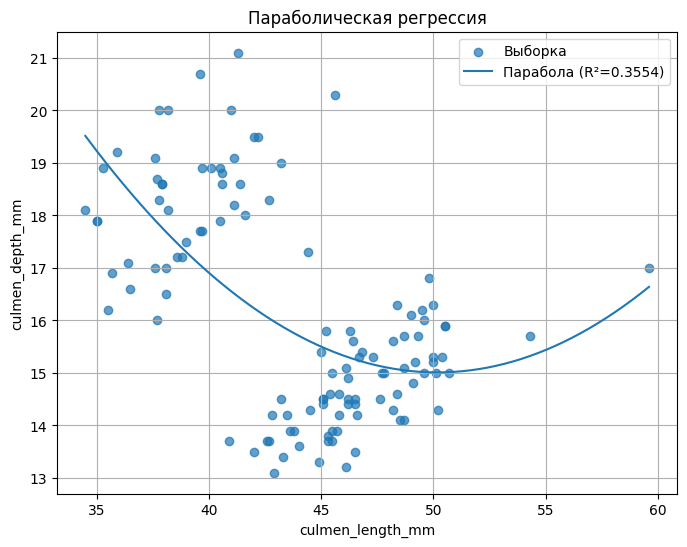

In [ ]:
b0, b1, b2, R2 = parabolic_regression(df, 'culmen_length_mm', 'culmen_depth_mm')

Коэффициенты $b_0, b_1, b_2$ найдены методом наименьших квадратов с использованием функции numpy.polyfit.

Коэффициент детерминации параболической модели составил 0.3554. Положительный
коэффициент при 𝑥² свидетельствует о выпуклости параболы вниз

5. Для заданной выборки построить корреляционную кривую логарифмическая функция:
$y=β_0+β_1lnx$

In [ ]:
def log_regression(df, col_x, col_y):

    x = df[col_x].values
    y = df[col_y].values

    ln_x = np.log(x)

    # мнк
    b1, b0 = np.polyfit(ln_x, y, 1)

    print("Логарифмическая регрессия:")
    print(f"y = {b0:.4f} + ({b1:.4f}) * ln(x)")

    y_pred = b0 + b1 * ln_x

    # R^2
    SS_res = np.sum((y - y_pred) ** 2)
    SS_tot = np.sum((y - y.mean()) ** 2)
    R2 = 1 - SS_res / SS_tot

    print(f"R^2 = {R2:.4f}")

    x_line = np.linspace(x.min(), x.max(), 200)
    y_line = b0 + b1 * np.log(x_line)

    plt.figure(figsize=(8, 6))
    plt.scatter(x, y, label='Выборка')
    plt.plot(x_line, y_line, label=f'Логарифмическая (R²={R2:.4f})')

    plt.xlabel(col_x)
    plt.ylabel(col_y)
    plt.title('Логарифмическая регрессия')
    plt.legend()
    plt.grid(True)

    plt.show()

    return b0, b1, R2

Логарифмическая регрессия:
y = 54.2139 + (-10.0818) * ln(x)
R^2 = 0.2981


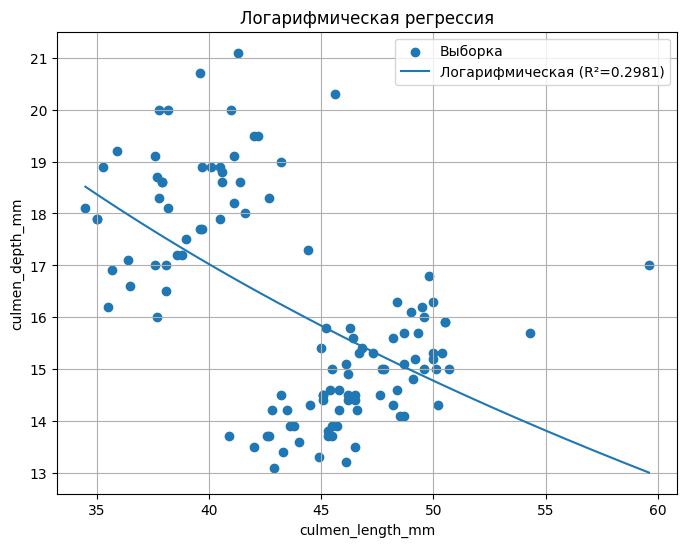

In [ ]:
b0, b1, R2 = log_regression(df, 'culmen_length_mm', 'culmen_depth_mm')

Коэффициент детерминации логарифмической модели составил 0.2981, это значение ниже, чем у параболической модели, что говорит о том, что эта модель описывает выборку хуже.




## Выводы

В ходе работы был проведён регрессионный анализ зависимости между двумя признаками ($X$ — длина клюва, $Y$ — высота клюва). Построенные линейные модели регрессии $y$ на $x$ и $x$ на $y$ показали наличие обратной связи: с увеличением длины клюва его высота уменьшается, и наоборот.

Сравнение выборочного корреляционного отношения ($\eta_{yx} = 0.6956$, $\eta_{xy} = 0.7271$) с модулем линейного коэффициента корреляции ($|r_{xy}| = 0.5303$) показывает, что выборочные данные не согласованы с предположением, что случайные величины связаны линейной связью ($\eta > |r|$).

Среди нелинейных моделей параболическая регрессия ($R^2 = 0.3554$) показывает лучшие результаты по сравнению с логарифмической ($R^2 = 0.2981$), однако обе модели объясняют не более $36\%$ вариации результативного признака.